## Capstone Project- Financial Fraud Detection

### Problem Statement-
Design a fraud detection system to identify fraudulent credit card transactions in real-time. The system should detect suspicious activities such as unauthorized transactions, unusual spending patterns, and fraudulent card usage to prevent financial losses for both cardholders and financial institutions.

## Tasks to Perform-
• What are the dimensions (number of rows and columns) of the dataset?

• How many unique values are there in each categorical variable?

• What is the distribution of numerical variables in the dataset?

• Are there any missing values in the dataset? If so, how should they be handled?

• What are the summary statistics (mean, median, min, max, etc.) for numerical variables?

• Is there any correlation between numerical variables? If so, how strong is the correlation?

• How does the distribution of an amt differ across is_fraud categories?

• Are there any outliers in the city_pop and amt?

• Are there any trends or patterns in the data over time (if applicable)?

• How does the target variable (if available) distribute across different categories?

• Are there any unusual or unexpected values in the dataset that require further investigation?

• Are there any potential data entry errors or inconsistencies in the dataset?

• How does the distribution of numerical variables vary between different groups or segments of the dataset?

• What are the top factors that influence the target variable, if applicable?

• Write an analysis report on performing exploratory data analysis (EDA) using Python in the context of building a fraud detection system for the financial industry.

In [1]:
# Import the necessary libraries
import pandas as pd # data organisation 
import numpy as np  # scientific computing
import matplotlib.pyplot as plt # visualisation
import seaborn as sns # visualisation

In [2]:
# load the data set
cc_data = pd.read_csv("Financial Fraud Detection_Datasets/cc_data.csv")
location_data = pd.read_csv("Financial Fraud Detection_Datasets/location_data.csv")

#### # Task-1  What are the dimensions (number of rows and columns) of the dataset?

In [3]:
print("Dimensions of cc_data:", cc_data.shape)
print(f"The number of rows in the dataset are : {cc_data.shape[0]} and number of columns in the dataset are : {cc_data.shape[1]}")
print("The Name of the columns are :", cc_data.columns.to_list())

Dimensions of cc_data: (389002, 23)
The number of rows in the dataset are : 389002 and number of columns in the dataset are : 23
The Name of the columns are : ['index', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']


#### Task-2 How many unique values are there in each categorical variable?

In [4]:
categorical_columns = cc_data.select_dtypes(include=['object']).columns
for cat in categorical_columns:
    print(f"Unique values in column '{cat}': {cc_data[cat].nunique()}")
    print("=" * 80)

Unique values in column 'trans_date_trans_time': 293627
Unique values in column 'merchant': 693
Unique values in column 'category': 14
Unique values in column 'first': 352
Unique values in column 'last': 481
Unique values in column 'gender': 2
Unique values in column 'street': 979
Unique values in column 'city': 890
Unique values in column 'state': 51
Unique values in column 'job': 492
Unique values in column 'dob': 964
Unique values in column 'trans_num': 389002


#### Task-3 What is the distribution of numerical variables in the dataset?

In [5]:
cc_data.head()

,index,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,151888,23-03-2019 03:06,3586008444788260,"fraud_Ferry, Lynch and Kautzer",misc_net,1.24,Crystal,Fuller,F,000 Jennifer Mills,...,47.4974,-122.0107,50489,Osteopath,29-02-1984,ff66e2310bf7a2a05e65d6b0a363aa5b,1332471978,47.352172,-121.644080,0
1,1185025,10-05-2020 11:28,4671727014157740,fraud_Bogisich Inc,grocery_pos,112.57,Kenneth,Edwards,M,3653 Ryan Crossroad,...,40.8618,-85.6067,2304,Retail banker,25-07-1955,f1edcfa2102065f5f76375c2d20b9081,1368185292,40.265726,-85.914050,0
2,10818,07-01-2019 13:31,377993105397617,fraud_Mohr-Bayer,shopping_net,6.69,Nathan,Martinez,M,586 Thomas Cliffs,...,44.8755,-88.1555,5548,Mining engineer,11-09-1975,0caa0ca338d1d2903b92bb42d8905768,1325943086,44.512954,-88.693464,0
3,975275,30-01-2020 18:49,4710826438164840000,fraud_Langworth LLC,personal_care,100.69,Juan,Henry,M,9795 Lori Island Suite 346,...,48.8328,-108.3961,192,Further education lecturer,04-01-1964,c7d25a5388311ebd7f2eef77459376ac,1359571786,47.909634,-109.008657,0
4,346814,12-06-2019 03:04,372382441451095,fraud_Hills-Witting,shopping_net,7.80,Brent,Terrell,M,502 Rice Plaza Apt. 979,...,41.8948,-73.9767,2471,Heritage manager,21-01-1966,8e1306b47052ac10fe48512de79edf71,1339470288,41.534838,-74.449927,0


In [6]:
cc_data.describe().T

,count,mean,std,min,25%,50%,75%,max
index,389002.0,6.485205e+05,3.745744e+05,1.100000e+01,3.241842e+05,6.486485e+05,9.735032e+05,1.296674e+06
cc_num,389002.0,4.191512e+17,1.311579e+18,6.041621e+10,1.800429e+14,3.521417e+15,4.642255e+15,4.992346e+18
amt,389002.0,7.044215e+01,1.622039e+02,1.000000e+00,9.660000e+00,4.757000e+01,8.307750e+01,2.739012e+04
zip,389002.0,4.881806e+04,2.687938e+04,1.257000e+03,2.623700e+04,4.817400e+04,7.201100e+04,9.978300e+04
lat,389002.0,3.853312e+01,5.074596e+00,2.002710e+01,3.462050e+01,3.935430e+01,4.194040e+01,6.669330e+01
long,389002.0,-9.023766e+01,1.374586e+01,-1.656723e+02,-9.679800e+01,-8.747690e+01,-8.015800e+01,-6.795030e+01
city_pop,389002.0,8.868084e+04,3.012101e+05,2.300000e+01,7.430000e+02,2.456000e+03,2.032800e+04,2.906700e+06
unix_time,389002.0,1.349251e+09,1.285085e+07,1.325376e+09,1.338751e+09,1.349267e+09,1.359460e+09,1.371817e+09
merch_lat,389002.0,3.853168e+01,5.109400e+00,1.902980e+01,3.471939e+01,3.936107e+01,4.195601e+01,6.706428e+01
merch_long,389002.0,-9.023667e+01,1.375731e+01,-1.666696e+02,-9.690544e+01,-8.744684e+01,-8.025383e+01,-6.695654e+01


In [7]:
print("Distribution of the numerical columns in the dataset :")
cc_data[["amt", "city_pop"]].describe()

Distribution of the numerical columns in the dataset :


,amt,city_pop
count,389002.000000,3.890020e+05
mean,70.442148,8.868084e+04
std,162.203915,3.012101e+05
min,1.000000,2.300000e+01
25%,9.660000,7.430000e+02
50%,47.570000,2.456000e+03
75%,83.077500,2.032800e+04
max,27390.120000,2.906700e+06


#### Task 4: Are there any missing values in the dataset? If so, how should they be handled?

In [8]:
print("The missing values in the dataset are: ")
cc_data.isnull().sum()

The missing values in the dataset are: 


index                    0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

##### There are no missing values in the dataset. If there are missing values then these should be replaces by appropriate value (mean/median/calculated) based on the distribution of column.

#### Task 5: What are the summary statistics (mean, median, min, max, etc.) for numerical variables?

In [9]:
numerical_columns = ["amt", "city_pop"] 
print("The summary statistics of the numerical columns in the dataset are :")
cc_data[numerical_columns].describe()

The summary statistics of the numerical columns in the dataset are :


,amt,city_pop
count,389002.000000,3.890020e+05
mean,70.442148,8.868084e+04
std,162.203915,3.012101e+05
min,1.000000,2.300000e+01
25%,9.660000,7.430000e+02
50%,47.570000,2.456000e+03
75%,83.077500,2.032800e+04
max,27390.120000,2.906700e+06


#### Task 6: Is there any correlation between numerical variables? If so, how strong is the correlation?

In [10]:
correlation_matrix = cc_data[numerical_columns].corr()
print("The correlation matrix of the numerical columns in the dataset is :")
correlation_matrix

The correlation matrix of the numerical columns in the dataset is :


,amt,city_pop
amt,1.000000,0.007271
city_pop,0.007271,1.000000


##### The correlation coefficient value between amt and citypopulation is  0.0072 which is very very small or negligible So there is no correlation between amt and city population.

#### Task 7: How does the distribution of an amt differ across is_fraud categories?

In [11]:
# Statistical Analysis
print("Statistical Analysis of the 'amt' column for fraudulent and non-fraudulent transactions:")
print("Fraudulent Transactions:")
print(cc_data[cc_data["is_fraud"] == 1]["amt"].describe())
print("Non-Fraudulent Transactions:")
print(cc_data[cc_data["is_fraud"] == 0]["amt"].describe())


Statistical Analysis of the 'amt' column for fraudulent and non-fraudulent transactions:
Fraudulent Transactions:
count    2252.000000
mean      518.328677
std       389.127281
min         1.180000
25%       147.882500
50%       365.285000
75%       888.342500
max      1294.830000
Name: amt, dtype: float64
Non-Fraudulent Transactions:
count    386750.000000
mean         67.834157
std         156.227752
min           1.000000
25%           9.620000
50%          47.330000
75%          82.500000
max       27390.120000
Name: amt, dtype: float64


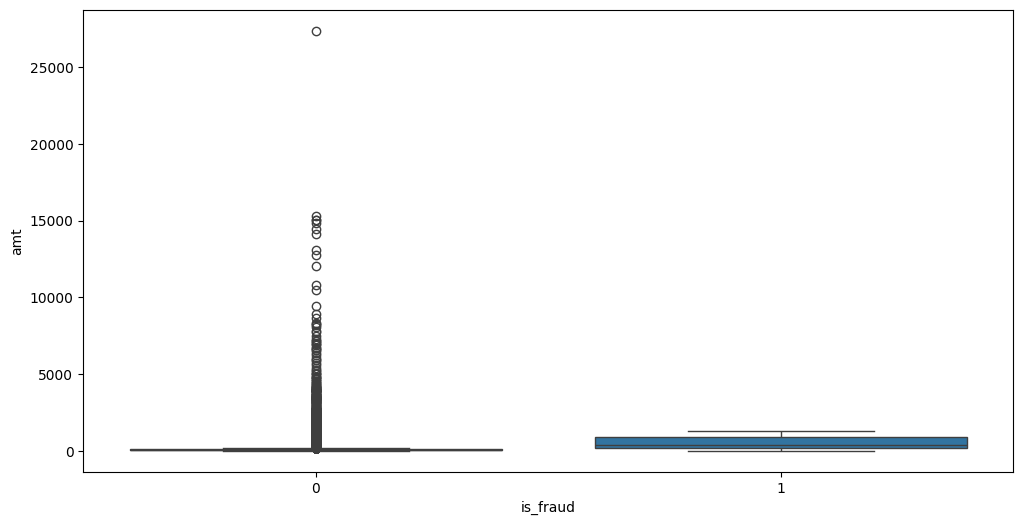

In [12]:
# Visualization of the distribution of the 'amt' column for fraudulent and non-fraudulent transactions
plt.figure(figsize=(12, 6))
sns.boxplot(x='is_fraud', y='amt', data=cc_data)
plt.show()

#### Task 8: Are there any outliers in the city_pop and amt?

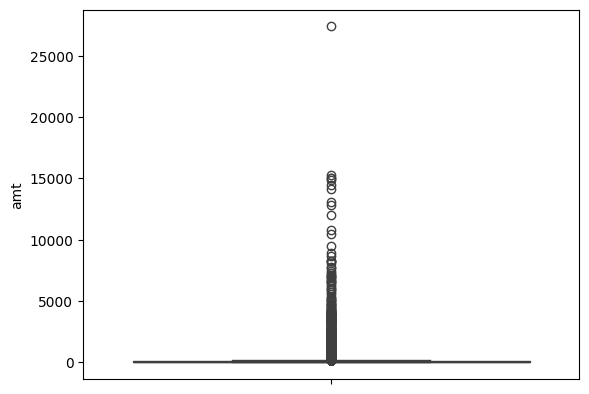

In [13]:
# Draw the boxplot to identify outliers in each numerical column.
sns.boxplot(data= cc_data["amt"])
plt.show()

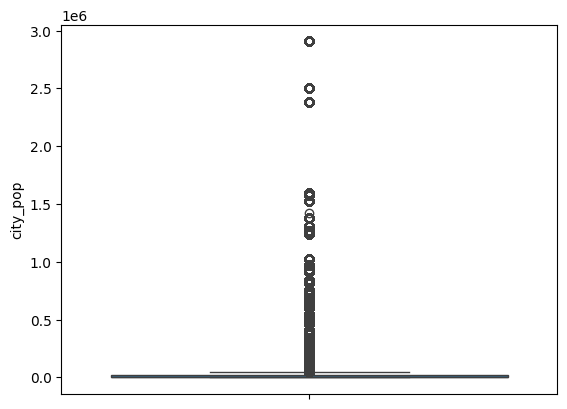

In [14]:
sns.boxplot(data= cc_data["city_pop"])
plt.show()

In [15]:
## Find out the number of outliers in the 'amt' column using the IQR method
Q1 = cc_data['amt'].quantile(0.25)
Q3 = cc_data['amt'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR    
upper_bound = Q3 + 1.5 * IQR
cc_data_outliers = cc_data[(cc_data['amt'] < lower_bound) | (cc_data['amt'] > upper_bound)]
print(f"Number of outliers in the 'amt' column: {cc_data_outliers.shape[0]}")

Number of outliers in the 'amt' column: 20377


In [16]:
## Find out the number of outliers in the 'city population' column using the IQR method
Q1 = cc_data['city_pop'].quantile(0.25)
Q3 = cc_data['city_pop'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR    
upper_bound = Q3 + 1.5 * IQR
cc_data_outliers = cc_data[(cc_data['city_pop'] < lower_bound) | (cc_data['city_pop'] > upper_bound)]
print(f"Number of outliers in the 'city population' column: {cc_data_outliers.shape[0]}")

Number of outliers in the 'city population' column: 72813


#### Task 9: Are there any trends or patterns in the data over time (if applicable)?

In [17]:
cc_data[["trans_date_trans_time", "amt"]].head(3)

,trans_date_trans_time,amt
0,23-03-2019 03:06,1.24
1,10-05-2020 11:28,112.57
2,07-01-2019 13:31,6.69


In [18]:
cc_data[["trans_date_trans_time", "amt"]].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 389002 entries, 0 to 389001
Data columns (total 2 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   trans_date_trans_time  389002 non-null  object 
 1   amt                    389002 non-null  float64
dtypes: float64(1), object(1)
memory usage: 5.9+ MB


In [ ]:
# cc_data["trans_date_trans_time"]=pd.to_datetime(cc_data["trans_date_trans_time"])
# cc_data_sorted = cc_data.sort_values(by='trans_date_trans_time')
# plt.plot(cc_data_sorted['trans_date_trans_time'], cc_data_sorted['amt'])
# plt.show()

#### Task 10: How does the target variable (if available) distribute across different categories?


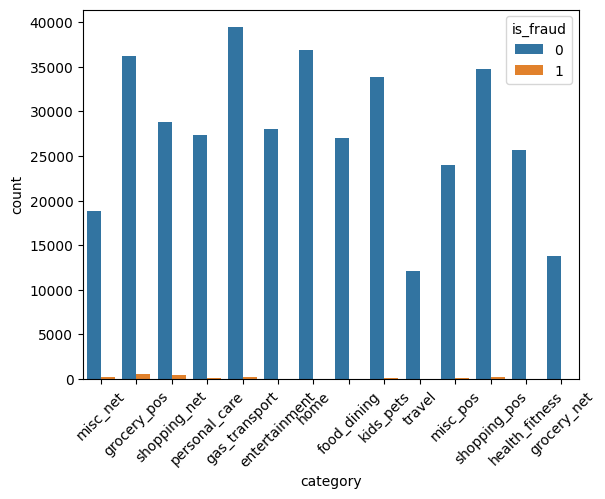

In [22]:
cc_data['category'].unique()
# is_fraud column distribution over the category column 
sns.countplot(x='category', hue='is_fraud', data=cc_data)
plt.xticks(rotation=45)
plt.show()

#### Task 11: Are there any unusual or unexpected values in the dataset that require further investigation?

In [23]:
cc_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 389002 entries, 0 to 389001
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   index                  389002 non-null  int64  
 1   trans_date_trans_time  389002 non-null  object 
 2   cc_num                 389002 non-null  int64  
 3   merchant               389002 non-null  object 
 4   category               389002 non-null  object 
 5   amt                    389002 non-null  float64
 6   first                  389002 non-null  object 
 7   last                   389002 non-null  object 
 8   gender                 389002 non-null  object 
 9   street                 389002 non-null  object 
 10  city                   389002 non-null  object 
 11  state                  389002 non-null  object 
 12  zip                    389002 non-null  int64  
 13  lat                    389002 non-null  float64
 14  long                   389002 non-nu

In [24]:
cc_data.head()

,index,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,151888,23-03-2019 03:06,3586008444788260,"fraud_Ferry, Lynch and Kautzer",misc_net,1.24,Crystal,Fuller,F,000 Jennifer Mills,...,47.4974,-122.0107,50489,Osteopath,29-02-1984,ff66e2310bf7a2a05e65d6b0a363aa5b,1332471978,47.352172,-121.644080,0
1,1185025,10-05-2020 11:28,4671727014157740,fraud_Bogisich Inc,grocery_pos,112.57,Kenneth,Edwards,M,3653 Ryan Crossroad,...,40.8618,-85.6067,2304,Retail banker,25-07-1955,f1edcfa2102065f5f76375c2d20b9081,1368185292,40.265726,-85.914050,0
2,10818,07-01-2019 13:31,377993105397617,fraud_Mohr-Bayer,shopping_net,6.69,Nathan,Martinez,M,586 Thomas Cliffs,...,44.8755,-88.1555,5548,Mining engineer,11-09-1975,0caa0ca338d1d2903b92bb42d8905768,1325943086,44.512954,-88.693464,0
3,975275,30-01-2020 18:49,4710826438164840000,fraud_Langworth LLC,personal_care,100.69,Juan,Henry,M,9795 Lori Island Suite 346,...,48.8328,-108.3961,192,Further education lecturer,04-01-1964,c7d25a5388311ebd7f2eef77459376ac,1359571786,47.909634,-109.008657,0
4,346814,12-06-2019 03:04,372382441451095,fraud_Hills-Witting,shopping_net,7.80,Brent,Terrell,M,502 Rice Plaza Apt. 979,...,41.8948,-73.9767,2471,Heritage manager,21-01-1966,8e1306b47052ac10fe48512de79edf71,1339470288,41.534838,-74.449927,0


In [25]:
# Validate the latitude and longitude columns values
print(cc_data['lat'].between(-90, 90).all()) 
print(cc_data['long'].between(-180, 180).all())

True
True


In [26]:
# Verify the catrgories for gender column
print(cc_data['gender'].unique())

['F' 'M']


In [27]:
# validate the amt and city_pop columns values
print(cc_data['amt'].min(), cc_data['amt'].max())
print(cc_data['city_pop'].min(), cc_data['city_pop'].max())

1.0 27390.12
23 2906700


#### TAsk 12: Are there any potential data entry errors or inconsistencies in the dataset?

##### We can use a very similar investigation to answer this question as we used with previous question

#### Task 13: How does the distribution of numerical variables vary between different groups or segments of the dataset?

In [28]:
cc_data.head()

,index,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,151888,23-03-2019 03:06,3586008444788260,"fraud_Ferry, Lynch and Kautzer",misc_net,1.24,Crystal,Fuller,F,000 Jennifer Mills,...,47.4974,-122.0107,50489,Osteopath,29-02-1984,ff66e2310bf7a2a05e65d6b0a363aa5b,1332471978,47.352172,-121.644080,0
1,1185025,10-05-2020 11:28,4671727014157740,fraud_Bogisich Inc,grocery_pos,112.57,Kenneth,Edwards,M,3653 Ryan Crossroad,...,40.8618,-85.6067,2304,Retail banker,25-07-1955,f1edcfa2102065f5f76375c2d20b9081,1368185292,40.265726,-85.914050,0
2,10818,07-01-2019 13:31,377993105397617,fraud_Mohr-Bayer,shopping_net,6.69,Nathan,Martinez,M,586 Thomas Cliffs,...,44.8755,-88.1555,5548,Mining engineer,11-09-1975,0caa0ca338d1d2903b92bb42d8905768,1325943086,44.512954,-88.693464,0
3,975275,30-01-2020 18:49,4710826438164840000,fraud_Langworth LLC,personal_care,100.69,Juan,Henry,M,9795 Lori Island Suite 346,...,48.8328,-108.3961,192,Further education lecturer,04-01-1964,c7d25a5388311ebd7f2eef77459376ac,1359571786,47.909634,-109.008657,0
4,346814,12-06-2019 03:04,372382441451095,fraud_Hills-Witting,shopping_net,7.80,Brent,Terrell,M,502 Rice Plaza Apt. 979,...,41.8948,-73.9767,2471,Heritage manager,21-01-1966,8e1306b47052ac10fe48512de79edf71,1339470288,41.534838,-74.449927,0


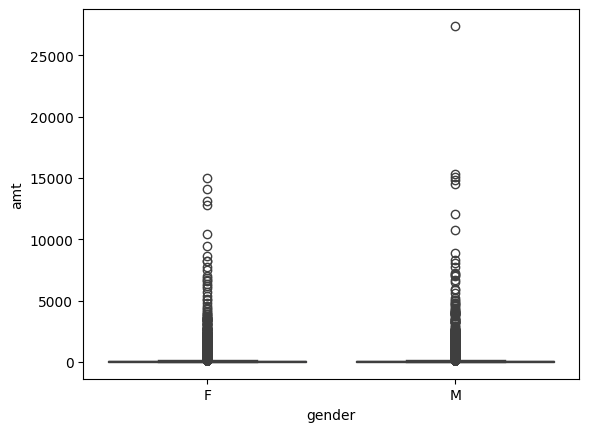

In [29]:
# Distribution of amount with respect to the gender column
sns.boxplot(x='gender', y='amt', data=cc_data)
plt.show()

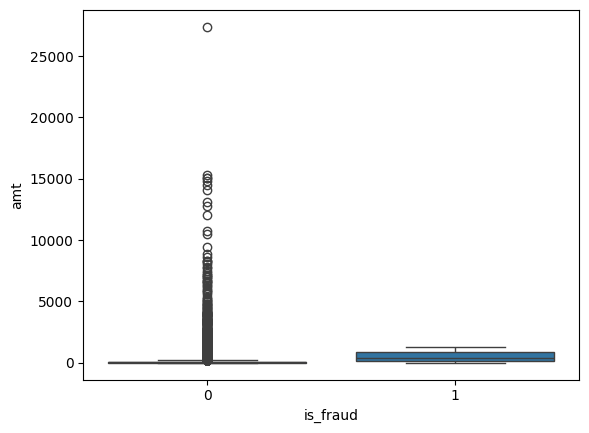

In [30]:
# Distribution of amount with respect to the gender column
sns.boxplot(x='is_fraud', y='amt', data=cc_data)
plt.show()

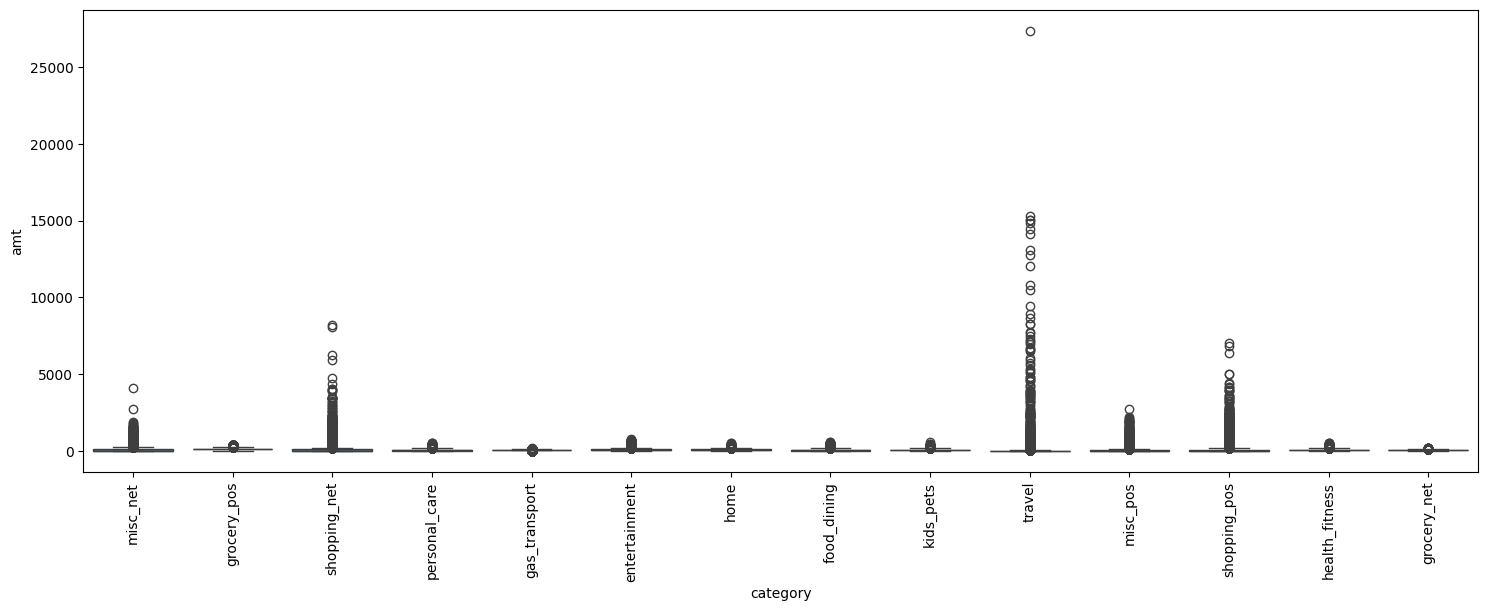

In [35]:
# Distribution of amount with respect to the gender column
plt.figure(figsize=(18, 6))
sns.boxplot(x='category', y='amt', data=cc_data)
plt.xticks(rotation=90)
plt.show()

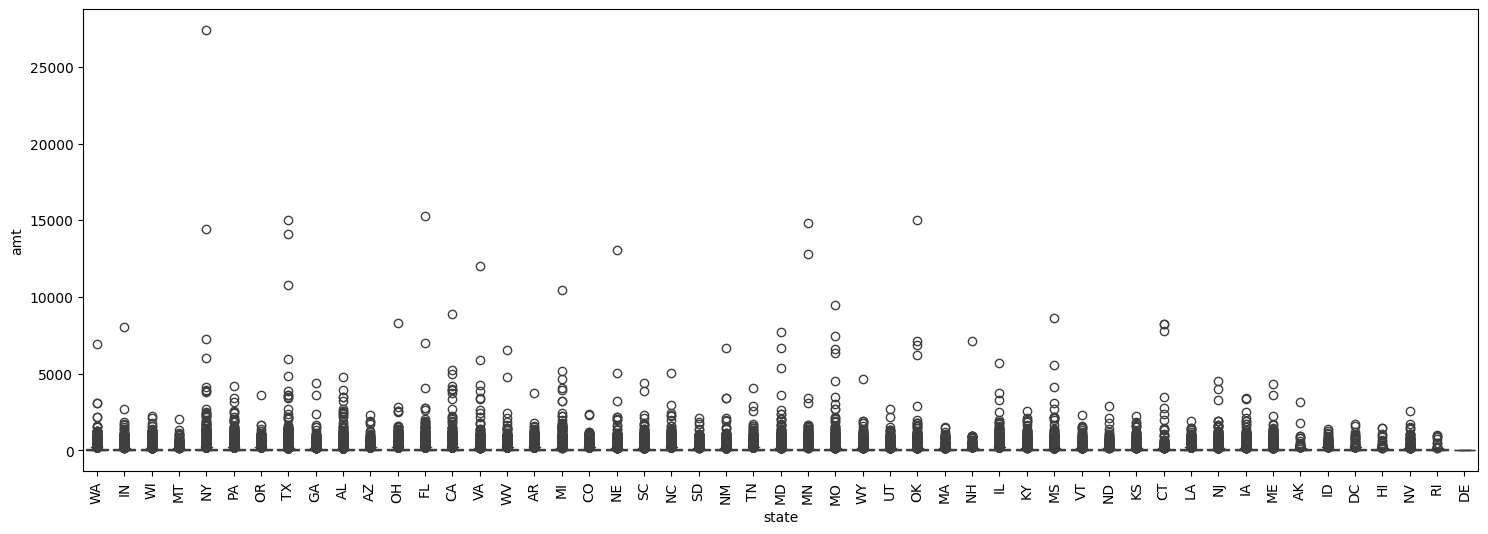

In [36]:
# Distribution of amount with respect to the gender column
plt.figure(figsize=(18, 6))
sns.boxplot(x='state', y='amt', data=cc_data)
plt.xticks(rotation=90)
plt.show()

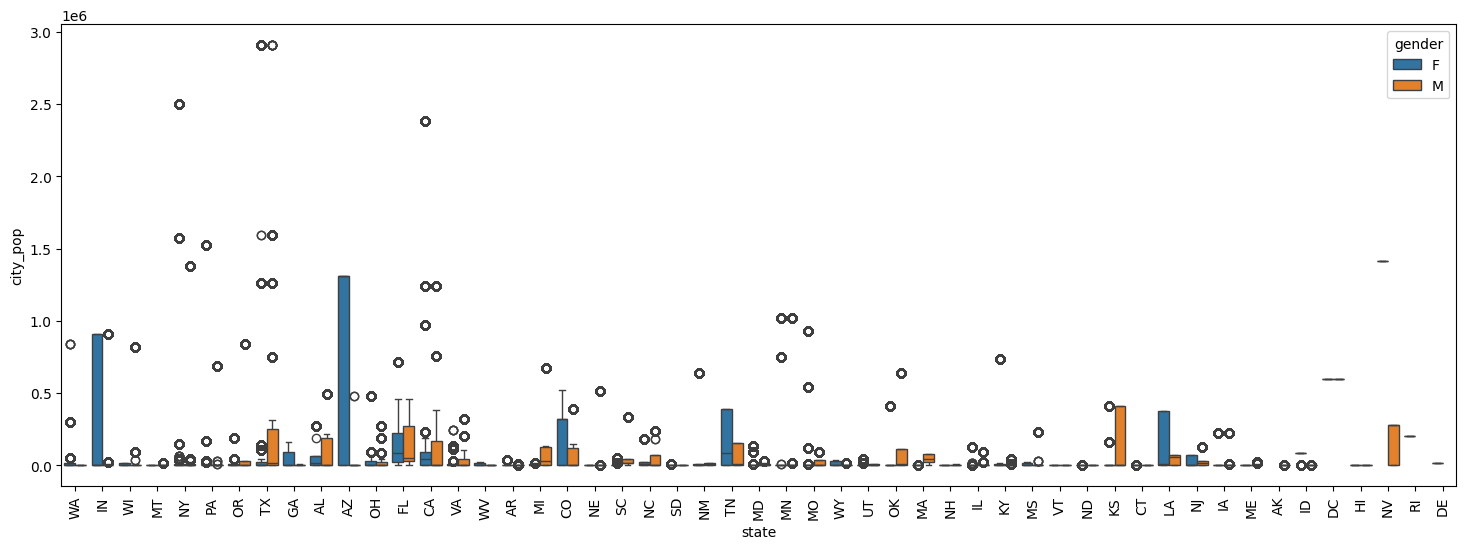

In [38]:
# Distribution of city population with respect to the state column
plt.figure(figsize=(18, 6))
sns.boxplot(x='state', y='city_pop', hue ='gender', data=cc_data)
plt.xticks(rotation=90)
plt.show()

#### Task 13: What are the top factors that influence the target variable, if applicable?

In [39]:
cc_data.columns

Index(['index', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

In [40]:
column_of_interest = [ 'category','amt', 'gender', 'state','city_pop', 'job', 'is_fraud']
data = cc_data[column_of_interest]
data.head()

,category,amt,gender,state,city_pop,job,is_fraud
0,misc_net,1.24,F,WA,50489,Osteopath,0
1,grocery_pos,112.57,M,IN,2304,Retail banker,0
2,shopping_net,6.69,M,WI,5548,Mining engineer,0
3,personal_care,100.69,M,MT,192,Further education lecturer,0
4,shopping_net,7.80,M,NY,2471,Heritage manager,0


In [43]:
correlation_matrix = data[["amt", "city_pop", "is_fraud"]].corr()
correlation_matrix

,amt,city_pop,is_fraud
amt,1.000000,0.007271,0.210706
city_pop,0.007271,1.000000,0.001176
is_fraud,0.210706,0.001176,1.000000


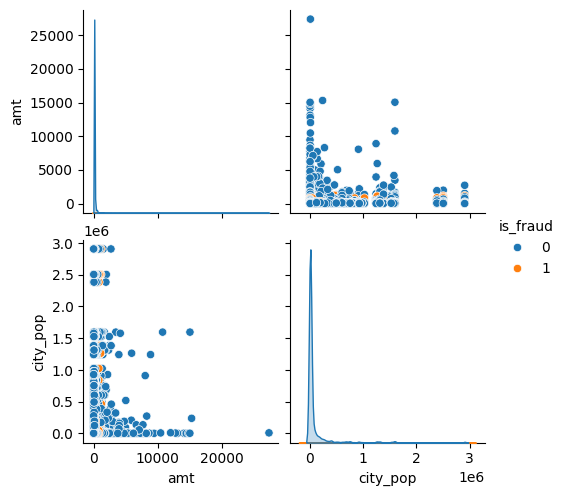

In [ ]:
sns.pairplot(data[["amt", "city_pop"]], hue='is_fraud') 
plt.show()

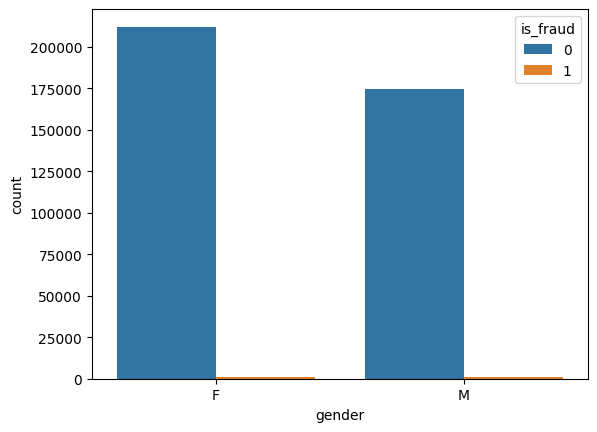

In [46]:
sns.countplot(x='gender', hue='is_fraud', data=cc_data) 
plt.show()

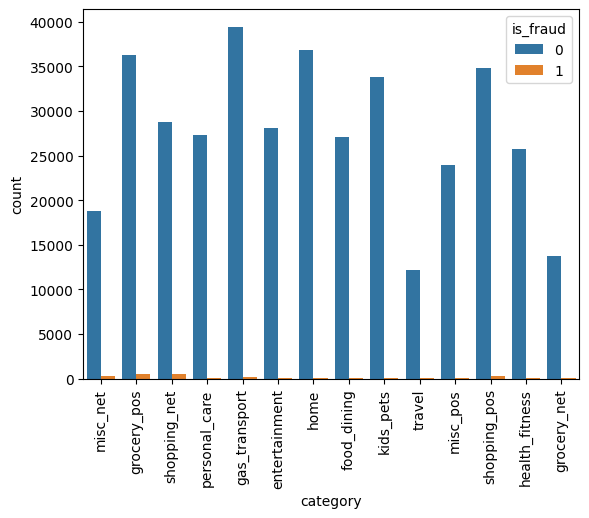

In [48]:
sns.countplot(x='category', hue='is_fraud', data=cc_data) 
plt.xticks(rotation=90)
plt.show()

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [56]:
data.head()

,category,amt,gender,state,city_pop,job,is_fraud
0,misc_net,1.24,F,WA,50489,Osteopath,0
1,grocery_pos,112.57,M,IN,2304,Retail banker,0
2,shopping_net,6.69,M,WI,5548,Mining engineer,0
3,personal_care,100.69,M,MT,192,Further education lecturer,0
4,shopping_net,7.80,M,NY,2471,Heritage manager,0


In [57]:
data = pd.get_dummies(data, columns=['category', 'gender', 'state', 'job'], drop_first=True)
data.head()

,amt,city_pop,is_fraud,category_food_dining,category_gas_transport,category_grocery_net,category_grocery_pos,category_health_fitness,category_home,category_kids_pets,...,job_Video editor,job_Visual merchandiser,job_Volunteer coordinator,job_Warden/ranger,job_Waste management officer,job_Water engineer,job_Water quality scientist,job_Web designer,job_Wellsite geologist,job_Writer
0,1.24,50489,0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,112.57,2304,0,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,6.69,5548,0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,100.69,192,0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,7.80,2471,0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [58]:
X = data.drop('is_fraud', axis=1)
y = data['is_fraud']

In [59]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 311201 samples
Testing set size: 77801 samples


In [60]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [61]:
# Evaluate the model on the test set
y_pred = dt.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     77344
           1       0.65      0.62      0.64       457

    accuracy                           1.00     77801
   macro avg       0.83      0.81      0.82     77801
weighted avg       1.00      1.00      1.00     77801



Dataset Understanding: Examine the financial transaction dataset using Python to understand its structure, variables, and size.

Data Cleaning: Check for missing values, duplicate records, and invalid or inconsistent transaction data.

Categorical Analysis: Analyze variables such as transaction category, gender, state, merchant, and occupation.

Numerical Analysis: Study transaction amount and city population using descriptive statistics and visualizations.

Fraud Distribution: Identify the proportion of fraudulent and non-fraudulent transactions and assess class imbalance.

Correlation Analysis: Examine relationships between transaction features and the is_fraud target variable.

Fraud Amount Analysis: Compare transaction amounts between fraudulent and legitimate transactions.

Outlier Detection: Use boxplots and the IQR method to identify unusual transaction values.

Visualization: Use Matplotlib and Seaborn to visualize fraud patterns and relationships between variables.

Model Preparation: Use EDA findings to select useful features and prepare the dataset for fraud-detection machine-learning models.